**Instituto Brasileiro de Ensino, Desenvolvimento e Pesquisa**

Programa de Pós-Graduação em Administração Pública — Mestrado Profissional

**Disciplina:** Avaliação de Políticas Públicas com Dados  
**Atividade:** Seleção nos observáveis, pareamento e escore de propensão  
**Grupo:** Analécia Borato, Fabricio Santana, Giovanni Brígido, Paulo Ceser

# Bolsa Família e evasão escolar

## Estimação do ATT com pareamento, IPW e escores logit/ML

Esta entrega replica e estende a análise da AIBF II realizada em aula. O
desfecho original, frequência nos últimos sete dias, é substituído por
**evasão escolar**. Todos os métodos respondem a mesma pergunta:

> Entre as crianças e adolescentes beneficiários que estudavam no ano
> anterior, qual foi o efeito médio de viver em um domicílio beneficiario
> do Bolsa Família sobre a probabilidade de abandonar a escola?

O estimando é o **ATT**, expresso em pontos percentuais. A análise compara
pareamento 1:1 e ponderação IPW para ATT, usando escores estimados por
regressão logística e por random forest calibrado. SMD e love plots avaliam
balanceamento. A interpretação causal é explicitamente condicionada a
ignorabilidade, positividade, consistência e ausência de interferência.

## 1. Desenho, dados e hipóteses

A AIBF II é observacional. A unidade é a pessoa de 6 a 17 anos. O tratamento
ocorre no domicílio: `D=1` se algum morador é titular do cartão do Bolsa
Família. O grupo de comparação é apenas o **controle cadastrado (C1)**; o
controle não cadastrado (C2) é excluído porque passou por um processo de
seleção diferente para o Cadastro Único.

O desfecho `dropout` vale 1 para abandono e 0 para permanência, entre pessoas
que estudavam no ano anterior. Portanto, ATT positivo significa aumento da
evasão e ATT negativo significa redução.

O conjunto de ajuste preserva as covariáveis pré-tratamento usadas na aula:
idade, sexo, escolaridade do chefe, número de moradores, cômodos,
dormitórios e água canalizada. Elas representam demografia e vulnerabilidade
domiciliar. Não ajustamos por frequência, faltas, série atual ou outras
variáveis escolares contemporâneas, pois podem ser consequências do
tratamento ou do próprio processo que produz o desfecho.

Identificação requer:

1. **Ignorabilidade:** `(Y(0), Y(1)) independent of D | X`;
2. **Positividade:** perfis tratados possuem controles C1 comparáveis;
3. **Consistência:** o tratamento observado corresponde a uma versão
   suficientemente bem definida do programa;
4. **SUTVA/não interferência:** o benefício de uma família não altera o
   resultado potencial de outra.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
CORES = {"antes": "#C23B33", "pareamento": "#167D8D", "ipw": "#D18B18"}
RANDOM_STATE = 42

In [2]:
caminho = Path("data/aibf_ii_educacao.csv")
if not caminho.exists():
    caminho = Path.cwd() / "data/aibf_ii_educacao.csv"
aibf = pd.read_csv(caminho)
print(f"Base bruta: {aibf.shape[0]:,} pessoas, {aibf['cod_dtm'].nunique():,} domicílios")

Base bruta: 56,367 pessoas, 11,372 domicílios


In [3]:
# Tratamento domiciliar: existe ao menos um titular do cartão no domicílio.
tratamento_dom = (aibf.groupby("cod_dtm")["s02a10"]
                   .transform(lambda s: int((s == 1).any())))
aibf["D"] = tratamento_dom
aibf["feminino"] = (aibf["s02ad"] == 2).astype(float)
aibf["agua"] = (aibf["agua_canalizada"] == 1).astype(float)

COVARIAVEIS = ["s02af", "feminino", "educ_chefe", "n_moradores",
               "n_comodos", "n_dormitorios", "agua"]
ROTULOS = {
    "s02af": "Idade", "feminino": "Sexo feminino",
    "educ_chefe": "Escolaridade do chefe", "n_moradores": "Moradores",
    "n_comodos": "Cômodos", "n_dormitorios": "Dormitórios",
    "agua": "Água canalizada"
}

# C1 e beneficiários somente; idade escolar, dropout observado e casos completos.
filtro = (
    aibf["estrato_amostral"].isin(["beneficiario", "controle"])
    & aibf["s02af"].between(6, 17)
    & aibf["dropout"].notna()
)
dados = (aibf.loc[filtro, ["cod_dtm", "D", "dropout", *COVARIAVEIS]]
         .dropna()
         .rename(columns={"dropout": "Y"})
         .reset_index(drop=True))

# Checagens que impedem mudancas silenciosas no recorte.
assert set(dados["D"].unique()) == {0, 1}
assert set(dados["Y"].unique()) <= {0, 1}
assert dados[COVARIAVEIS].notna().all().all()
resumo_amostra = (dados.groupby("D")["Y"]
                  .agg(n="size", domicilios=lambda s: dados.loc[s.index, "cod_dtm"].nunique(),
                       evasão="mean")
                  .rename(index={0: "Controle C1", 1: "Beneficiário"}))
resumo_amostra.rename(columns={'domicilios': 'domicílios'})

,n,domicílios,evasão
D,,,
Controle C1,2430,1506,0.0786
Beneficiário,6054,3150,0.0689


A exclusão de observações sem `dropout` não é mero detalhe operacional: o
desfecho só é definido para quem estudava no ano anterior. Assim, o ATT se
refere a essa subpopulação, não a todas as crianças pobres. Se o Bolsa
Família afetou anteriormente a probabilidade de estar nessa subpopulação,
condiciona-la pode introduzir seleção; a base transversal não permite
eliminar essa ameaça.

## 2. Associação bruta

Antes do ajuste, comparamos as médias observadas. Essa diferença mistura o
efeito do programa e a seleção de famílias mais vulneráveis para o benefício.

In [4]:
media_trat = dados.loc[dados.D == 1, "Y"].mean()
media_ctrl = dados.loc[dados.D == 0, "Y"].mean()
diferenca_bruta = media_trat - media_ctrl
pd.DataFrame({
    "medida": ["Evasão beneficiários", "Evasão controle C1", "Diferença bruta"],
    "proporção": [media_trat, media_ctrl, diferenca_bruta],
    "pontos_percentuais": 100 * np.array([media_trat, media_ctrl, diferenca_bruta])
})

,medida,proporção,pontos_percentuais
0,Evasão beneficiários,0.0689,6.8880
1,Evasão controle C1,0.0786,7.8601
2,Diferença bruta,-0.0097,-0.9721


## 3. Escores de propensão: logística e machine learning

Estimamos `e(X)=P(D=1|X)` por dois modelos. A logística impõe uma forma
funcional aditiva e linear no logito. O random forest captura não linearidades
e interações, mas suas probabilidades podem ser inadequadas para ponderação;
por isso usamos folhas regularizadas, calibração sigmoide e predições
**out-of-fold** em cinco partições. A logística também é avaliada out-of-fold
para uma comparação simétrica.

AUC e calibração são apresentados como diagnósticos auxiliares. O critério
causal decisivo será o balanceamento produzido pelo uso do escore, não a
capacidade de prever tratamento.

In [5]:
X = dados[COVARIAVEIS]
D = dados["D"].astype(int).to_numpy()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelo_logit = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
)
modelo_rf_base = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=25, max_features="sqrt",
    n_jobs=-1, random_state=RANDOM_STATE
)
modelo_rf = CalibratedClassifierCV(modelo_rf_base, method="sigmoid", cv=3)

dados["ps_logit"] = cross_val_predict(
    modelo_logit, X, D, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]
dados["ps_rf"] = cross_val_predict(
    modelo_rf, X, D, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

diagnostico_escore = pd.DataFrame({
    "modelo": ["Logística", "Random forest calibrado"],
    "AUC": [roc_auc_score(D, dados.ps_logit), roc_auc_score(D, dados.ps_rf)],
    "minimo": [dados.ps_logit.min(), dados.ps_rf.min()],
    "maximo": [dados.ps_logit.max(), dados.ps_rf.max()]
})
diagnostico_escore.rename(columns={'minimo': 'mínimo', 'maximo': 'máximo'})

,modelo,AUC,mínimo,máximo
0,Logística,0.6067,0.3201,0.9238
1,Random forest calibrado,0.6131,0.4426,0.8457


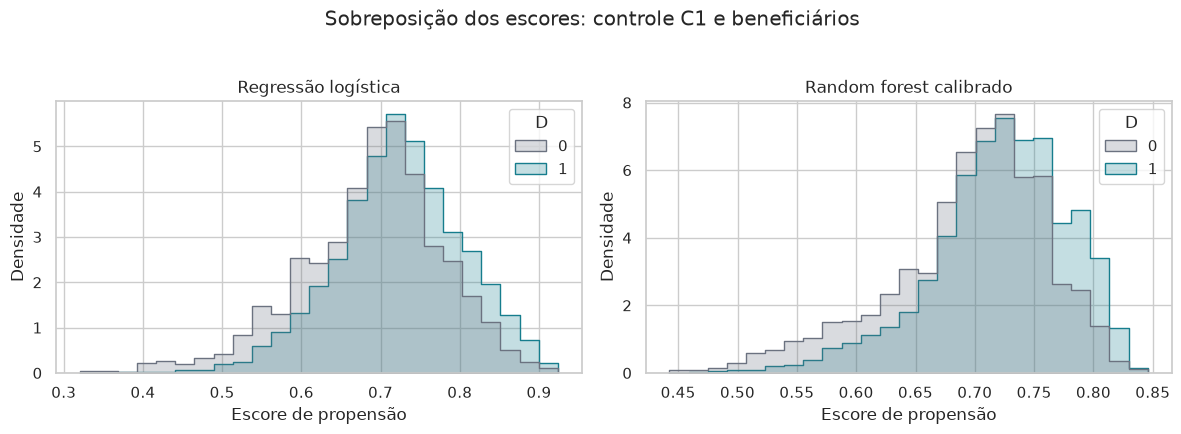

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, (coluna, titulo) in zip(
    axes, [("ps_logit", "Regressão logística"), ("ps_rf", "Random forest calibrado")]
):
    sns.histplot(data=dados, x=coluna, hue="D", stat="density",
                 common_norm=False, bins=25, element="step", alpha=.25,
                 palette={0: "#6B7280", 1: "#167D8D"}, ax=ax)
    ax.set(title=titulo, xlabel="Escore de propensão", ylabel="Densidade")
fig.suptitle("Sobreposição dos escores: controle C1 e beneficiários", y=1.03)
plt.tight_layout()

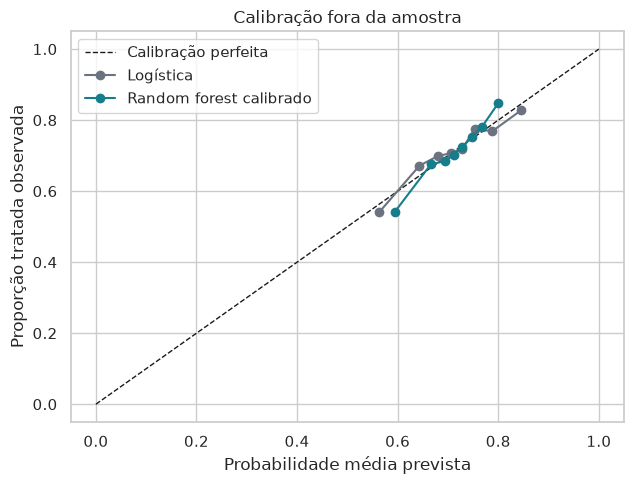

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Calibração perfeita")
for nome, coluna, cor in [
    ("Logística", "ps_logit", "#6B7280"),
    ("Random forest calibrado", "ps_rf", "#167D8D")
]:
    observado, previsto = calibration_curve(D, dados[coluna], n_bins=8,
                                             strategy="quantile")
    ax.plot(previsto, observado, "o-", color=cor, label=nome)
ax.set(xlabel="Probabilidade média prevista", ylabel="Proporção tratada observada",
       title="Calibração fora da amostra")
ax.legend()
plt.tight_layout()

## 4. Métodos para o ATT

Para cada modelo de escore aplicamos:

- **Pareamento 1:1 com reposição:** cada tratado recebe o controle de escore
  mais próximo. Reposição é apropriada porque há menos controles e preserva
  a qualidade dos pares. O peso de um controle é o número de vezes em que e
  reutilizado.
- **IPW para ATT (Hajek):** tratados recebem peso 1; controles recebem
  `e(X)/(1-e(X))`. As médias ponderadas são normalizadas dentro dos grupos.

Em ambos os casos restringimos a análise ao suporte comum, definido pela
interseção dos intervalos observados dos escores nos dois grupos. A
estimativa passa a ser o ATT na população tratada com suporte observado.

In [8]:
def suporte_comum(df, ps_col):
    mins = df.groupby("D")[ps_col].min()
    maxs = df.groupby("D")[ps_col].max()
    limite_inf, limite_sup = max(mins), min(maxs)
    mascara = df[ps_col].between(limite_inf, limite_sup)
    return mascara, limite_inf, limite_sup


def estimar_att(df, ps_col):
    mascara, inf, sup = suporte_comum(df, ps_col)
    sub = df.loc[mascara].copy()
    tratado = sub.D.eq(1).to_numpy()
    ps = sub[ps_col].to_numpy()
    y = sub.Y.to_numpy()

    # Pareamento no escore com reposição.
    pos_trat = np.flatnonzero(tratado)
    pos_ctrl = np.flatnonzero(~tratado)
    nn = NearestNeighbors(n_neighbors=1).fit(ps[pos_ctrl].reshape(-1, 1))
    dist, viz = nn.kneighbors(ps[pos_trat].reshape(-1, 1))
    pos_pareados = pos_ctrl[viz.ravel()]
    att_match = np.mean(y[pos_trat] - y[pos_pareados])
    w_match = np.zeros(len(sub))
    w_match[pos_trat] = 1
    np.add.at(w_match, pos_pareados, 1)

    # IPW/Hajek para ATT. Tratados mantem sua distribuição; controles a reproduzem.
    w_ipw = np.where(tratado, 1.0, ps / (1 - ps))
    att_ipw = (np.average(y[tratado], weights=w_ipw[tratado])
               - np.average(y[~tratado], weights=w_ipw[~tratado]))

    return {
        "dados": sub, "att_match": att_match, "att_ipw": att_ipw,
        "w_match": w_match, "w_ipw": w_ipw,
        "distancias": dist.ravel(), "limites": (inf, sup),
        "tratados_retidos": int(tratado.sum()),
        "controles_retidos": int((~tratado).sum())
    }


def inferencia_cluster(df, pesos):
    # EP sandwich do contraste de Hajek, agrupado por domicílio.
    # E condicional ao escore: não incorpora a incerteza de reestima-lo.
    d = df.D.to_numpy().astype(bool)
    y = df.Y.to_numpy()
    w = np.asarray(pesos)
    mu1 = np.average(y[d], weights=w[d])
    mu0 = np.average(y[~d], weights=w[~d])
    influencia = np.zeros(len(df))
    influencia[d] = w[d] * (y[d] - mu1) / w[d].sum()
    influencia[~d] = -w[~d] * (y[~d] - mu0) / w[~d].sum()
    por_dom = pd.Series(influencia).groupby(df.cod_dtm.reset_index(drop=True)).sum()
    g = len(por_dom)
    ep = np.sqrt((g / (g - 1)) * np.square(por_dom).sum())
    return ep


ajustes = {"Logística": estimar_att(dados, "ps_logit"),
           "Random forest calibrado": estimar_att(dados, "ps_rf")}

linhas = []
for modelo, a in ajustes.items():
    ep_match = inferencia_cluster(a["dados"], a["w_match"])
    ep_ipw = inferencia_cluster(a["dados"], a["w_ipw"])
    linhas.extend([
        {"modelo_escore": modelo, "metodo": "Pareamento 1:1",
         "ATT": a["att_match"], "EP_cluster": ep_match,
         "IC95_inf": a["att_match"] - 1.96 * ep_match,
         "IC95_sup": a["att_match"] + 1.96 * ep_match},
        {"modelo_escore": modelo, "metodo": "IPW-ATT",
         "ATT": a["att_ipw"], "EP_cluster": ep_ipw,
         "IC95_inf": a["att_ipw"] - 1.96 * ep_ipw,
         "IC95_sup": a["att_ipw"] + 1.96 * ep_ipw}
    ])
resultados = pd.DataFrame(linhas)
resultados_pp = resultados.copy()
for coluna in ["ATT", "EP_cluster", "IC95_inf", "IC95_sup"]:
    resultados_pp[coluna + "_pp"] = 100 * resultados_pp[coluna]
resultados_pp[["modelo_escore", "metodo", "ATT_pp", "EP_cluster_pp",
               "IC95_inf_pp", "IC95_sup_pp"]].rename(columns={"modelo_escore": "modelo do escore", "metodo": "método", "EP_cluster_pp": "EP agrupado (p.p.)", "IC95_inf_pp": "IC95% inferior", "IC95_sup_pp": "IC95% superior"})

,modelo do escore,método,ATT_pp,EP agrupado (p.p.),IC95% inferior,IC95% superior
0,Logística,Pareamento 1:1,-1.5529,1.0098,-3.5321,0.4262
1,Logística,IPW-ATT,-1.1068,0.7732,-2.6223,0.4087
2,Random forest calibrado,Pareamento 1:1,-2.3298,1.0425,-4.3730,-0.2866
3,Random forest calibrado,IPW-ATT,-1.1149,0.7484,-2.5817,0.3518


In [9]:
def ess(pesos):
    pesos = np.asarray(pesos)
    return pesos.sum() ** 2 / np.square(pesos).sum()

diag_metodos = []
for modelo, a in ajustes.items():
    sub = a["dados"]
    ctrl = sub.D.eq(0).to_numpy()
    diag_metodos.append({
        "modelo": modelo,
        "suporte": f"[{a['limites'][0]:.3f}; {a['limites'][1]:.3f}]",
        "tratados_retidos": a["tratados_retidos"],
        "controles_retidos": a["controles_retidos"],
        "distância_mediana_match": np.median(a["distancias"]),
        "distância_max_match": np.max(a["distancias"]),
        "ESS_controles_match": ess(a["w_match"][ctrl]),
        "peso_max_IPW_controle": a["w_ipw"][ctrl].max(),
        "ESS_controles_IPW": ess(a["w_ipw"][ctrl])
    })
pd.DataFrame(diag_metodos).rename(columns={'modelo': 'modelo do escore', 'tratados_retidos': 'tratados retidos', 'controles_retidos': 'controles retidos', 'ESS_controles_match': 'ESS controles pareamento', 'peso_max_IPW_controle': 'peso máximo IPW controle', 'ESS_controles_IPW': 'ESS controles IPW'})

,modelo do escore,suporte,tratados retidos,controles retidos,distância_mediana_match,distância_max_match,ESS controles pareamento,peso máximo IPW controle,ESS controles IPW
0,Logística,[0.372; 0.923],6053,2426,0.0000,0.0073,"1,025.6938",12.0350,"1,974.9814"
1,Random forest calibrado,[0.455; 0.843],6052,2429,0.0000,0.0029,"1,065.1633",5.3601,"2,234.0400"


A tabela anterior mostra também o tamanho efetivo da amostra (ESS). Ele cai
quando poucos controles recebem grande peso ou são reutilizados muitas vezes.
Logo, balanceamento excelente pode vir acompanhado de menor precisão; ambos
precisam ser examinados.

## 5. Balanceamento: SMD e love plots

A diferença padronizada de médias (SMD) mede desequilíbrio em unidades de
desvio-padrao. Usamos o desvio-padrao combinado **antes** do ajuste como
denominador fixo, inclusive depois do ajuste. Como regra pratica, `|SMD|<0,1`
é desejável. Para ATT, comparamos os tratados com a distribuição reponderada
dos controles.

In [10]:
def media_ponderada(x, w):
    return np.average(np.asarray(x), weights=np.asarray(w))


def tabela_smd(df, pesos=None):
    d = df.D.to_numpy().astype(bool)
    w = np.ones(len(df)) if pesos is None else np.asarray(pesos)
    linhas = []
    for var in COVARIAVEIS:
        x = df[var].to_numpy()
        m1 = media_ponderada(x[d], w[d])
        m0 = media_ponderada(x[~d], w[~d])
        # Denominador pré-ajuste, invariável entre os diagnósticos.
        sd_pool = np.sqrt((np.var(x[d], ddof=1) + np.var(x[~d], ddof=1)) / 2)
        linhas.append({"covariável": ROTULOS[var], "SMD": (m1 - m0) / sd_pool})
    return pd.DataFrame(linhas)


smd_antes = tabela_smd(dados).rename(columns={"SMD": "Antes"})
tabelas_smd = []
for modelo, a in ajustes.items():
    base = smd_antes.copy()
    base["Pareamento"] = tabela_smd(a["dados"], a["w_match"])["SMD"]
    base["IPW"] = tabela_smd(a["dados"], a["w_ipw"])["SMD"]
    base.insert(0, "Modelo", modelo)
    tabelas_smd.append(base)
smd_completo = pd.concat(tabelas_smd, ignore_index=True)
smd_completo

,Modelo,covariável,Antes,Pareamento,IPW
0,Logística,Idade,-0.0520,-0.0155,0.0046
1,Logística,Sexo feminino,0.0357,-0.0182,-0.0174
2,Logística,Escolaridade do chefe,-0.2566,0.0134,0.0115
3,Logística,Moradores,0.2322,0.0350,-0.0406
4,Logística,Cômodos,-0.1417,0.0176,0.0026
5,Logística,Dormitórios,-0.0851,0.0133,0.0086
6,Logística,Água canalizada,-0.2179,-0.0303,0.0155
7,Random forest calibrado,Idade,-0.0520,-0.0185,-0.0135
8,Random forest calibrado,Sexo feminino,0.0357,0.0069,0.0202
9,Random forest calibrado,Escolaridade do chefe,-0.2566,-0.0354,-0.0881


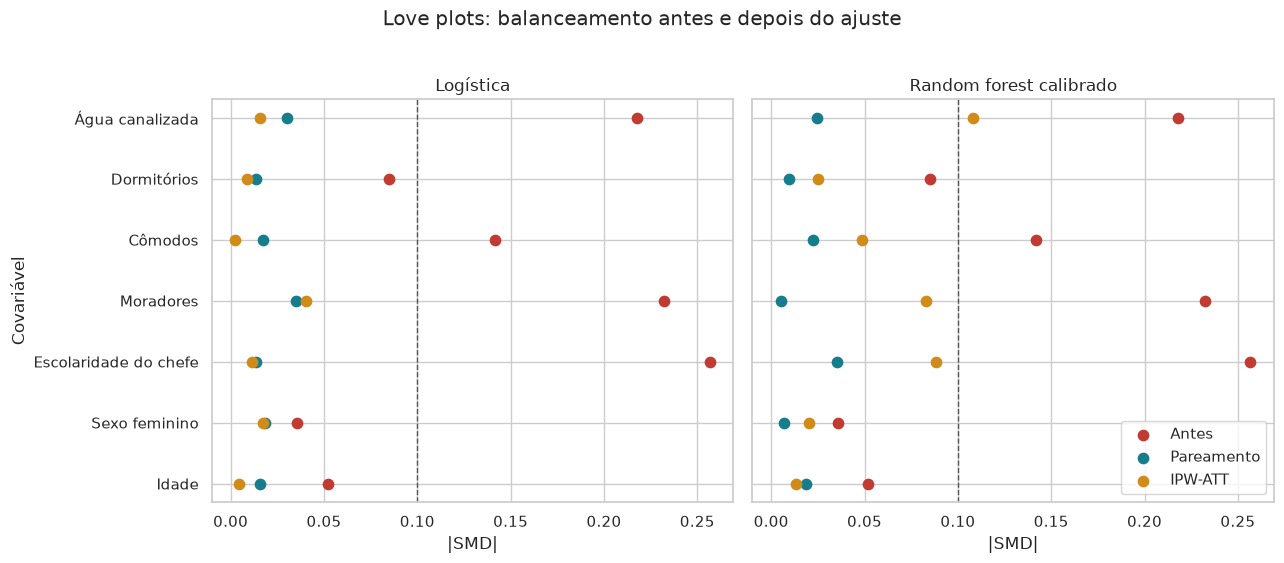

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, (modelo, tab) in zip(axes, smd_completo.groupby("Modelo", sort=False)):
    y = np.arange(len(tab))
    ax.scatter(tab["Antes"].abs(), y, s=55, color=CORES["antes"], label="Antes")
    ax.scatter(tab["Pareamento"].abs(), y, s=55, color=CORES["pareamento"], label="Pareamento")
    ax.scatter(tab["IPW"].abs(), y, s=55, color=CORES["ipw"], label="IPW-ATT")
    ax.axvline(.1, color="#555555", linestyle="--", linewidth=1)
    ax.set_yticks(y, tab["covariável"])
    ax.set_title(modelo)
    ax.set_xlabel("|SMD|")
    ax.invert_yaxis()
axes[0].set_ylabel("Covariável")
axes[1].legend(loc="lower right")
fig.suptitle("Love plots: balanceamento antes e depois do ajuste", y=1.02)
plt.tight_layout()

In [12]:
resumo_balanceamento = []
for modelo, tab in smd_completo.groupby("Modelo", sort=False):
    for metodo in ["Antes", "Pareamento", "IPW"]:
        resumo_balanceamento.append({
            "modelo": modelo, "metodo": metodo,
            "max_abs_SMD": tab[metodo].abs().max(),
            "n_acima_0_1": int((tab[metodo].abs() >= .1).sum())
        })
pd.DataFrame(resumo_balanceamento).rename(columns={'modelo': 'modelo do escore', 'metodo': 'método', 'max_abs_SMD': 'máximo |SMD|', 'n_acima_0_1': 'n acima de 0,1'})

,modelo do escore,método,máximo |SMD|,"n acima de 0,1"
0,Logística,Antes,0.2566,4
1,Logística,Pareamento,0.0350,0
2,Logística,IPW,0.0406,0
3,Random forest calibrado,Antes,0.2566,4
4,Random forest calibrado,Pareamento,0.0354,0
5,Random forest calibrado,IPW,0.1079,1


## 6. Síntese e interpretação

A leitura conjunta segue uma ordem deliberada:

1. verificar sobreposição e pesos extremos;
2. verificar se o método reduziu SMDs para abaixo de 0,1;
3. somente então comparar os ATTs entre métodos e modelos;
4. interpretar magnitudes em pontos percentuais, sem confundir estabilidade
   entre modelos com prova de identificacao.

Se logística e random forest produzem resultados próximos e bom
balanceamento, isso mostra **robustez as duas especificações observadas do
escore**. Não mostra que confundidores não medidos foram eliminados.

In [13]:
tabela_final = resultados_pp[["modelo_escore", "metodo", "ATT_pp",
                              "IC95_inf_pp", "IC95_sup_pp"]].copy()
tabela_final["diferenca_para_bruta_pp"] = tabela_final["ATT_pp"] - 100 * diferenca_bruta
tabela_final.rename(columns={'modelo_escore': 'modelo do escore', 'metodo': 'método', 'IC95_inf_pp': 'IC95% inferior', 'IC95_sup_pp': 'IC95% superior', 'diferenca_para_bruta_pp': 'diferença para bruta (p.p.)'}).round(3)

,modelo do escore,método,ATT_pp,IC95% inferior,IC95% superior,diferença para bruta (p.p.)
0,Logística,Pareamento 1:1,-1.5530,-3.5320,0.4260,-0.5810
1,Logística,IPW-ATT,-1.1070,-2.6220,0.4090,-0.1350
2,Random forest calibrado,Pareamento 1:1,-2.3300,-4.3730,-0.2870,-1.3580
3,Random forest calibrado,IPW-ATT,-1.1150,-2.5820,0.3520,-0.1430


Os resultados ajustados apontam para redução da evasão entre os
beneficiários. O IPW é especialmente estável a troca do modelo do escore:
cerca de **-1,11 ponto percentual** com logística ou random forest. O
pareamento é mais sensível: **-1,55 p.p.** com logística e **-2,33 p.p.**
com random forest. Essa diferença é coerente com seu menor ESS de controles
e com a reutilização de vizinhos.

Os intervalos de 95% são aproximações normais com erro-padrao agrupado por
domicílio. Eles reconhecem que crianças do mesmo domicílio não são
independentes, mas condicionam nos escores estimados e, portanto, podem
subestimar a incerteza total. No modelo principal (logística + IPW), o IC95%
aproximado é **[-2,62; 0,41] p.p.**: inclui zero, de modo que os dados são
compatíveis tanto com redução modesta quanto com efeito nulo. A conclusão
deve enfatizar magnitudes, intervalos e robustez, não uma classificação
binária por valor-p.

Nos diagnósticos, a logística deixa todas as covariáveis abaixo de 0,1 tanto
no pareamento quanto no IPW. O random forest também funciona bem no
pareamento, mas seu IPW deixa água canalizada ligeiramente acima do limiar
(`|SMD|=0,108`). Assim, maior AUC do ML não implica melhor ajuste causal; a
logística é o modelo mais convincente nesta aplicação pelo balanceamento.

O efeito ajustado deve ser descrito como uma diferença de risco: um ATT de
`-0,01`, por exemplo, equivale a **1 ponto percentual a menos de evasão**
entre beneficiários, relativamente ao contrafactual estimado sem benefício.
Não equivale a uma redução de 1% no risco relativo.

### O que os diagnósticos podem e não podem sustentar

SMD baixo confirma equilibrio apenas nas sete covariáveis medidas. Love plot,
AUC e calibração não testam ignorabilidade. Renda anterior detalhada,
motivação dos responsáveis, qualidade da escola, distância, oferta local e
choques familiares podem afetar simultaneamente recebimento e evasão. Se
algum deles permanecer associado a `D` depois de `X`, o ATT continuará
confundido, ainda que todos os pontos do love plot estejam próximos de zero.

Há ainda quatro limites substantivos:

- o tratamento domiciliar é uma fotografia, sem duração ou valor recebido;
- o desfecho é autorrelatado e condicionado a ter estudado no ano anterior;
- crianças do mesmo domicílio não são independentes;
- a restrição ao suporte comum limita a conclusão aos beneficiários
  comparáveis aos controles C1 observados.

Portanto, a formulação defensável é: **associação ajustada compatível com um
ATT causal sob ignorabilidade e demais hipóteses**, e não prova definitiva
de que o Bolsa Família causou a mudança estimada na evasão.

## 7. Conclusão

A análise substituiu o desfecho concentrado de frequência por evasão escolar,
manteve beneficiários e controles cadastrados sob um desenho comum e estimou
o ATT por quatro combinações de método e escore. Pareamento e IPW constroem
contrafactuais de maneiras diferentes; logística e random forest impõem
estruturas diferentes a probabilidade de tratamento. A convergencia ou
divergência entre eles deve ser julgada junto com suporte, ESS, SMD e love
plots.

O principal aprendizado não é escolher o número mais favoravel. É mostrar
que uma estimativa observacional só ganha interpretação causal quando o
conjunto de ajuste bloqueia todos os caminhos de confundimento relevantes,
algo que os dados observados não conseguem verificar por si mesmos.

## Referências incorporadas a entrega

- BRASIL. Ministério do Desenvolvimento Social. *Avaliação de Impacto do
  Programa Bolsa Família - 2a rodada (AIBF II)*. Brasília: MDS, 2012.
- DE BRAUW, A. et al. The Impact of Bolsa Família on Schooling. *World
  Development*, v. 70, p. 303-316, 2015.
- HERNAN, M. A.; ROBINS, J. M. *Causal Inference: What If*. Boca Raton:
  Chapman & Hall/CRC, 2020.
- KING, G.; NIELSEN, R. Why Propensity Scores Should Not Be Used for
  Matching. *Political Analysis*, v. 27, n. 4, p. 435-454, 2019.
- ROSENBAUM, P. R.; RUBIN, D. B. The central role of the propensity score in
  observational studies for causal effects. *Biometrika*, v. 70, n. 1,
  p. 41-55, 1983.
  